In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# load data
ds = xr.open_dataset('ncdiffusion_perday_pertransect.nc')   # data is plotted with temporal transect positions

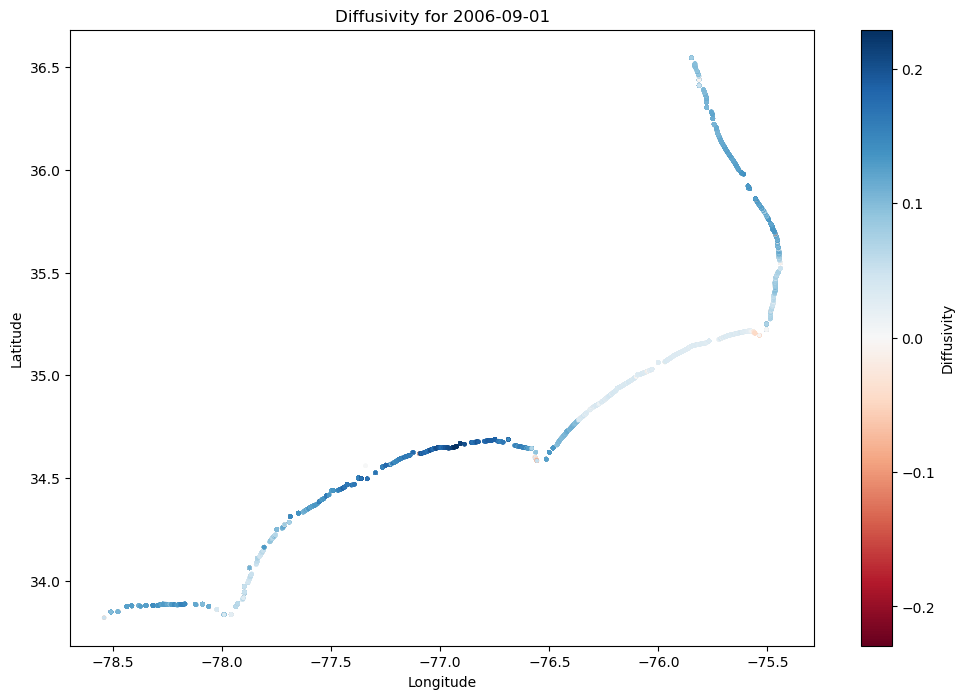

In [2]:
# plot for one time value
target_date = "2006-09-01"
snapshot = ds['diffusivity'].sel(time=target_date, method='nearest').squeeze()

max_val = np.nanmax(snapshot.values)
min_val = np.nanmin(snapshot.values)
limit = max(abs(max_val), abs(min_val))

plt.figure(figsize=(12, 8))
plt.scatter(
    snapshot.lon, 
    snapshot.lat, 
    c=snapshot.values,
    vmin=-limit, # symmetric colorbar, if comparing two different days be sure to check cbar limits
    vmax=limit,
    cmap='RdBu', 
    s=10, 
    edgecolors='none'
)

plt.colorbar(label='Diffusivity')
plt.title(f"Diffusivity for {target_date}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

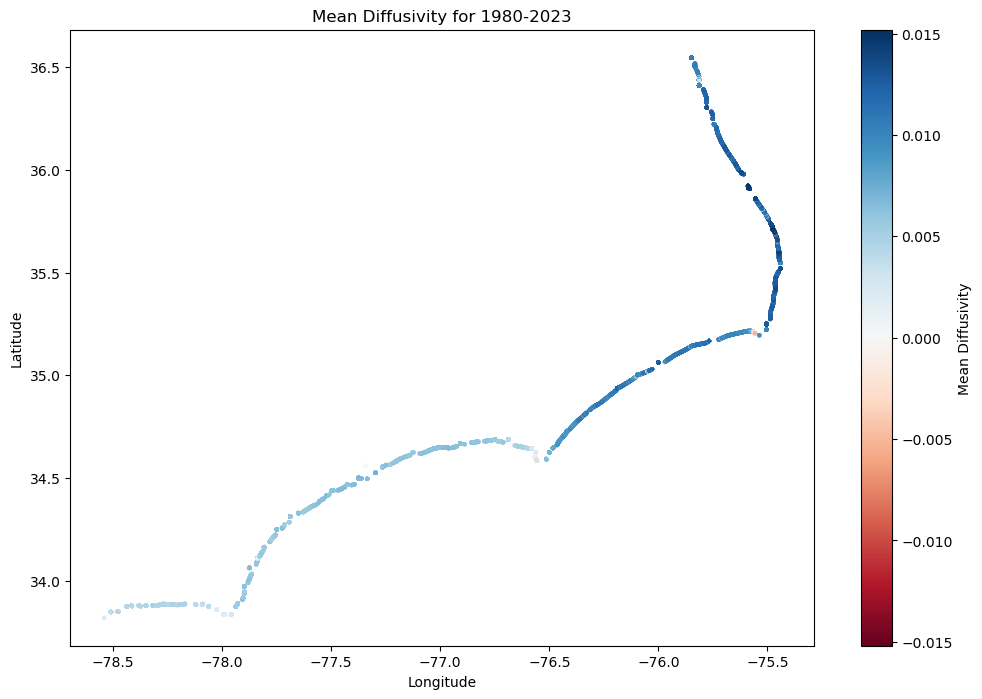

In [4]:
# plot mean for all time
mean_transport = ds['diffusivity'].mean(dim='time').compute()

mean_lon = ds['lon'].mean(dim='time') if 'time' in ds['lon'].dims else ds['lon']
mean_lat = ds['lat'].mean(dim='time') if 'time' in ds['lat'].dims else ds['lat']

max_val = np.nanmax(mean_transport.values)
min_val = np.nanmin(mean_transport.values)
limit = max(abs(max_val), abs(min_val))

plt.figure(figsize=(12, 8))
plt.scatter(
    mean_lon, 
    mean_lat, 
    c=mean_transport.values,
    vmin=-limit,                                        
    vmax=limit,
    cmap='RdBu', 
    s=10, 
    edgecolors='none'
)

plt.colorbar(label='Mean Diffusivity')
plt.title("Mean Diffusivity for 1980-2023")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()